# Global Life Expectancy Prediction — World Bank Data
Dataset: World Bank World Development Indicators

**Goal**: predict a country's life expectancy from health, economic, and education indicators — genuinely useful for identifying which factors most influence health outcomes, relevant to global health policy prioritization. Built on real institutional data you queried yourself, not a pre-cleaned Kaggle CSV.

## How this dataset was obtained
1. First we visit **databank.worldbank.org/source/world-development-indicators**
2. Under **Country**,we select "All" (or a broad set of countries)
3. Under **Series**,we search for and select these 8 indicators:
   - Life expectancy at birth, total (years) — `SP.DYN.LE00.IN`
   - GDP per capita (current US$) — `NY.GDP.PCAP.CD`
   - Current health expenditure (% of GDP) — `SH.XPD.CHEX.GD.ZS`
   - School enrollment, primary (% gross) — `SE.PRM.ENRR`
   - Immunization, measles (% of children ages 12-23 months) — `SH.IMM.MEAS`
   - Mortality rate, under-5 (per 1,000 live births) — `SH.DYN.MORT`
   - Prevalence of HIV, total (% of population ages 15-49) — `SH.DYN.AIDS.ZS`
   - Population, total — `SP.POP.TOTL`
4. Under **Time**,we select a range of recent years (2010-2020)
5. Then we click **Download options → CSV**

## 0. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#Makes the shapes appear larger for better understanding
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

---
# PHASE 1 — Load & Reshape
World Bank exports data in **wide format** — one row per Country+Indicator, one column per year. That's not directly usable for modeling , we want one row per Country-Year with each indicator as its own column , so the first real step is reshaping, genuine messy real-world data handling.

In [2]:
df_raw = pd.read_csv("data/worldbank_data.csv")
df_raw.head()

,Country Name,Country Code,Series Name,Series Code,2010 [YR2010],2011 [YR2011],2012 [YR2012],2013 [YR2013],2014 [YR2014],2015 [YR2015],2016 [YR2016],2017 [YR2017],2018 [YR2018],2019 [YR2019],2020 [YR2020]
0,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,60.702,61.25,61.735,62.188,62.26,62.27,62.646,62.406,62.443,62.941,61.454
1,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,560.621505463146,606.694676337726,651.417134470046,637.087099117099,625.054941813938,565.569730408751,522.082215583898,525.469770891619,491.337221382603,496.6025042585,510.787063366811
2,Afghanistan,AFG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,8.56967163,8.56190777,7.89716864,8.80596447,9.52887821,10.10534763,11.81859016,12.62081718,14.20841885,14.83131981,15.53361416
3,Afghanistan,AFG,"School enrollment, primary (% gross)",SE.PRM.ENRR,103.48560333252,101.542083740234,106.575317382812,107.942840576172,109.829452514648,106.773551940918,106.784042358398,106.54354095459,107.687660217285,109.075309753418,..
4,Afghanistan,AFG,"Immunization, measles (% of children ages 12-2...",SH.IMM.MEAS,62,64,59,57,60,62,64,64,66,57,57


In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2125 entries, 0 to 2124
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Country Name   2122 non-null   object
 1   Country Code   2120 non-null   object
 2   Series Name    2120 non-null   object
 3   Series Code    2120 non-null   object
 4   2010 [YR2010]  2120 non-null   object
 5   2011 [YR2011]  2120 non-null   object
 6   2012 [YR2012]  2120 non-null   object
 7   2013 [YR2013]  2120 non-null   object
 8   2014 [YR2014]  2120 non-null   object
 9   2015 [YR2015]  2120 non-null   object
 10  2016 [YR2016]  2120 non-null   object
 11  2017 [YR2017]  2120 non-null   object
 12  2018 [YR2018]  2120 non-null   object
 13  2019 [YR2019]  2120 non-null   object
 14  2020 [YR2020]  2120 non-null   object
dtypes: object(15)
memory usage: 249.1+ KB


## Reshape from wide (year columns) to long, then pivot indicators into columns

In [4]:
# Identify the year columns (they look like '2010 [YR2010]', '2011 [YR2011]', etc.)
year_cols = [c for c in df_raw.columns if '[YR' in c]

# Melt: one row per Country + Indicator + Year
df_long = df_raw.melt(
    id_vars=['Country Name', 'Country Code', 'Series Name', 'Series Code'],
    value_vars=year_cols,
    var_name='Year',
    value_name='Value'
)

# Clean the Year column: '2015 [YR2015]' -> 2015
df_long['Year'] = df_long['Year'].str.extract(r'(\d{4})').astype(int)

# Some cells are '..' for missing data — convert to actual NaN, then numeric
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

df_long.head()

,Country Name,Country Code,Series Name,Series Code,Year,Value
0,Afghanistan,AFG,"Life expectancy at birth, total (years)",SP.DYN.LE00.IN,2010,60.702000
1,Afghanistan,AFG,GDP per capita (current US$),NY.GDP.PCAP.CD,2010,560.621505
2,Afghanistan,AFG,Current health expenditure (% of GDP),SH.XPD.CHEX.GD.ZS,2010,8.569672
3,Afghanistan,AFG,"School enrollment, primary (% gross)",SE.PRM.ENRR,2010,103.485603
4,Afghanistan,AFG,"Immunization, measles (% of children ages 12-2...",SH.IMM.MEAS,2010,62.000000


In [5]:
# Pivot: one row per Country-Year, one column per indicator
df = df_long.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Series Name',
    values='Value'
).reset_index()

df.columns.name = None
df.head()

,Country Name,Country Code,Year,Current health expenditure (% of GDP),GDP per capita (current US$),"Immunization, measles (% of children ages 12-23 months)","Life expectancy at birth, total (years)","Mortality rate, under-5 (per 1,000 live births)","Population, total","Prevalence of HIV, total (% of population ages 15-49)","School enrollment, primary (% gross)"
0,Afghanistan,AFG,2010,8.569672,560.621505,62.0,60.702,88.0,28284089.0,0.1,103.485603
1,Afghanistan,AFG,2011,8.561908,606.694676,64.0,61.250,84.3,29347708.0,0.1,101.542084
2,Afghanistan,AFG,2012,7.897169,651.417134,59.0,61.735,80.8,30560034.0,0.1,106.575317
3,Afghanistan,AFG,2013,8.805964,637.087099,57.0,62.188,77.6,31622704.0,0.1,107.942841
4,Afghanistan,AFG,2014,9.528878,625.054942,60.0,62.260,74.6,32792523.0,0.1,109.829453


---
# PHASE 2 — Clean Column Names & Handle Missing Data

In [6]:
# Rename to short, code-friendly names
rename_map = {
    'Life expectancy at birth, total (years)': 'LifeExpectancy',
    'GDP per capita (current US$)': 'GDPPerCapita',
    'Current health expenditure (% of GDP)': 'HealthExpenditurePct',
    'School enrollment, primary (% gross)': 'SchoolEnrollment',
    'Immunization, measles (% of children ages 12-23 months)': 'MeaslesImmunization',
    'Mortality rate, under-5 (per 1,000 live births)': 'Under5Mortality',
    'Prevalence of HIV, total (% of population ages 15-49)': 'HIVPrevalence',
    'Population, total': 'Population',
}
df = df.rename(columns=rename_map)
df.head()

,Country Name,Country Code,Year,HealthExpenditurePct,GDPPerCapita,MeaslesImmunization,LifeExpectancy,Under5Mortality,Population,HIVPrevalence,SchoolEnrollment
0,Afghanistan,AFG,2010,8.569672,560.621505,62.0,60.702,88.0,28284089.0,0.1,103.485603
1,Afghanistan,AFG,2011,8.561908,606.694676,64.0,61.250,84.3,29347708.0,0.1,101.542084
2,Afghanistan,AFG,2012,7.897169,651.417134,59.0,61.735,80.8,30560034.0,0.1,106.575317
3,Afghanistan,AFG,2013,8.805964,637.087099,57.0,62.188,77.6,31622704.0,0.1,107.942841
4,Afghanistan,AFG,2014,9.528878,625.054942,60.0,62.260,74.6,32792523.0,0.1,109.829453


In [ ]:
df.isnull().sum()

In [7]:
# Drop rows missing the target — can't train/evaluate without it
df = df.dropna(subset=['LifeExpectancy'])

# For features, impute missing values with the median FOR THAT YEAR across countries
# (better than a single global median — accounts for the fact that e.g. HIV prevalence
# reporting has improved over time, so 2010 medians shouldn't fill 2020 gaps)
feature_cols = ['GDPPerCapita', 'HealthExpenditurePct', 'SchoolEnrollment',
                 'MeaslesImmunization', 'Under5Mortality', 'HIVPrevalence', 'Population']

for col in feature_cols:
    df[col] = df.groupby('Year')[col].transform(lambda x: x.fillna(x.median()))

# Drop any remaining rows with missing data (years/indicators too sparse to impute)
df = df.dropna(subset=feature_cols)
print(f"Final dataset: {len(df)} country-year rows")

Final dataset: 2904 country-year rows


---
# PHASE 3 — EDA

In [ ]:
df['LifeExpectancy'].describe()

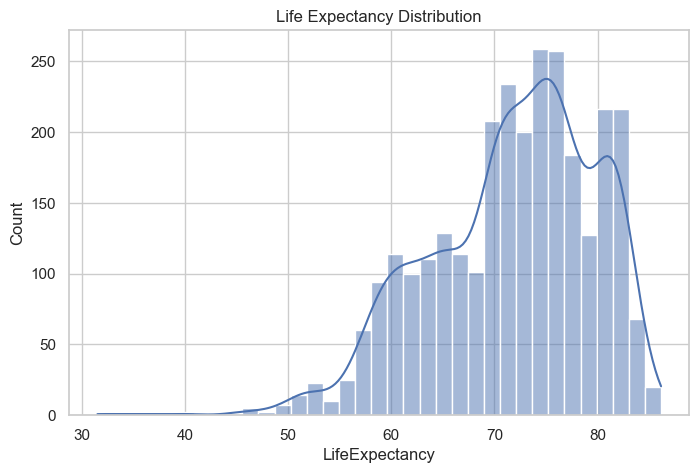

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['LifeExpectancy'], kde=True)
plt.title("Life Expectancy Distribution")
plt.show()

**Explanation:**

This histogram shows the distribution of life expectancy across all countries in the dataset. Most observations are concentrated between 70 and 80 years, indicating that the majority of countries have relatively high life expectancy. Very few countries have life expectancy below 50 years, making them rare cases. The smooth blue KDE curve highlights the overall trend, showing that the data is slightly left-skewed, with a longer tail towards lower life expectancy values. Overall, the distribution suggests that while most countries enjoy higher life expectancy, a smaller group still experiences significantly lower health outcomes.

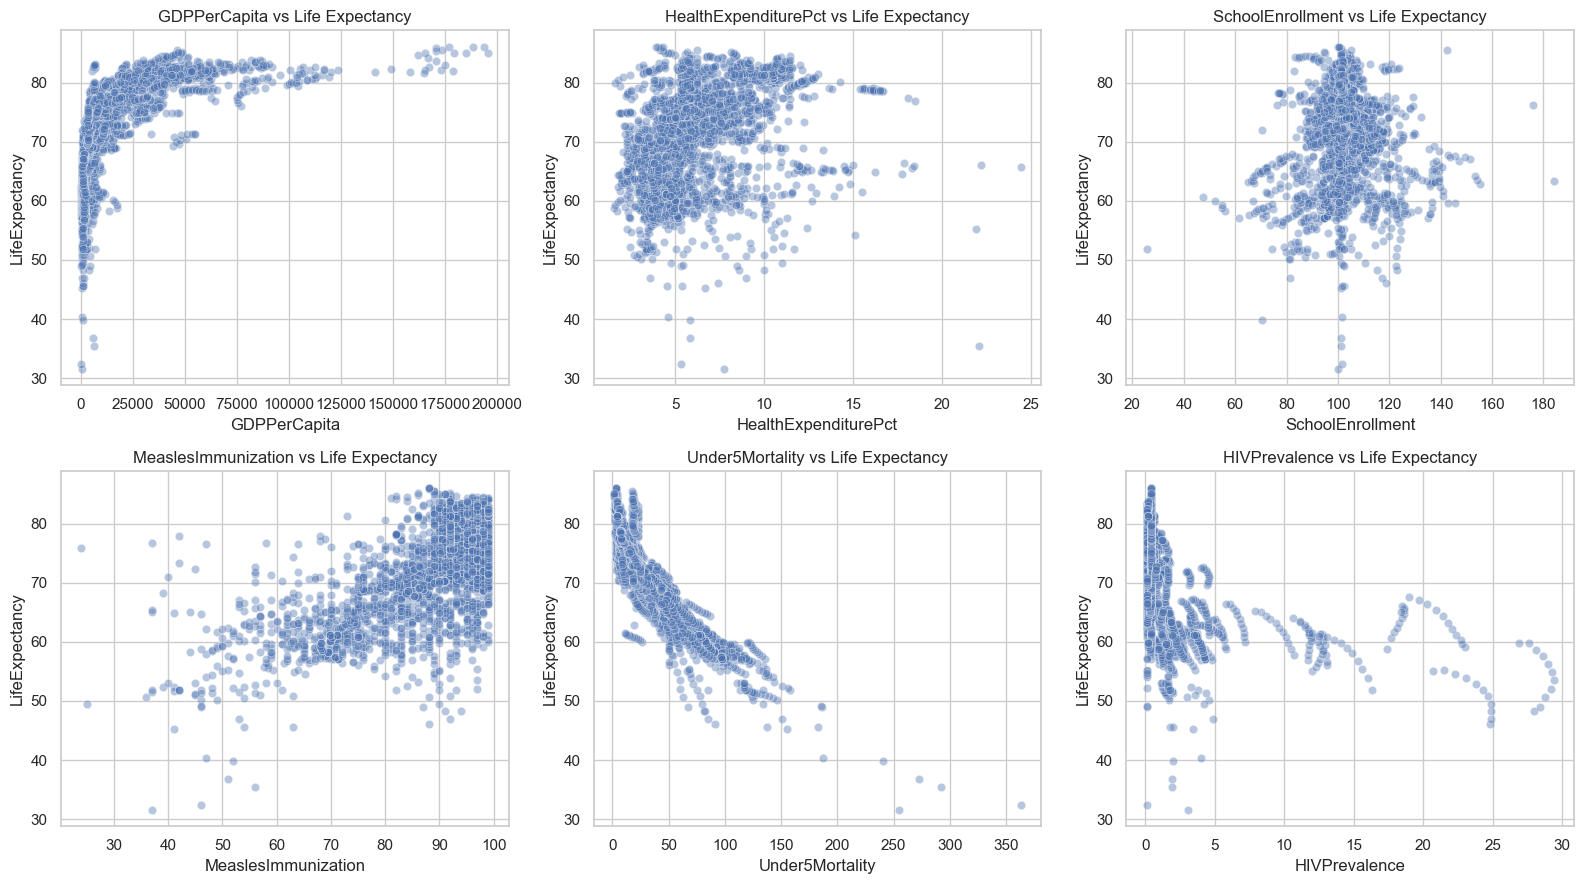

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), feature_cols[:6]):
    sns.scatterplot(data=df, x=col, y='LifeExpectancy', alpha=0.4, ax=ax)
    ax.set_title(f'{col} vs Life Expectancy')
plt.tight_layout()
plt.show()

The scatter plots reveal several meaningful relationships between the features and Life Expectancy. GDP per Capita and Measles Immunization show a positive correlation, indicating that wealthier countries and those with higher vaccination coverage generally have longer life expectancy. In contrast, Under-5 Mortality and HIV Prevalence exhibit a strong negative correlation, showing that higher child mortality and HIV prevalence are associated with lower life expectancy. Health Expenditure displays a moderate positive trend, while School Enrollment shows a weaker but generally positive relationship. Overall, Under-5 Mortality, GDP per Capita, and HIV Prevalence appear to be the strongest predictors of life expectancy and are likely to have the greatest influence on the machine learning model.

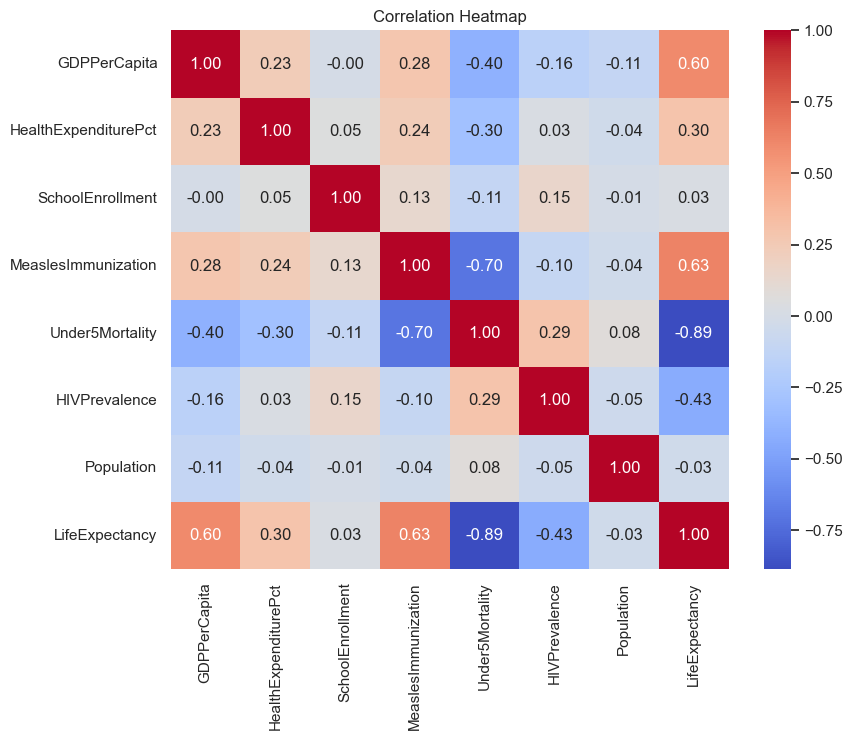

In [10]:
plt.figure(figsize=(9, 7))
corr_cols = feature_cols + ['LifeExpectancy']
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

**Findings:**

The correlation analysis shows that Under-5 Mortality has the strongest negative relationship with Life Expectancy (r = -0.89), making it the most influential predictor. In contrast, Measles Immunization (r = 0.63) and GDP per Capita (r = 0.60) exhibit strong positive correlations, suggesting that better healthcare and economic development are associated with longer lives. HIV Prevalence also shows a moderate negative correlation (r = -0.43), while Population and School Enrollment have little direct correlation with life expectancy. Additionally, GDP per Capita appears to be highly right-skewed (log-scale distributed), indicating that a logarithmic transformation could improve model performance by reducing the influence of extreme values.

---
# PHASE 4 — Feature Engineering

In [11]:
# GDP per capita and Population are typically heavily right-skewed — log-transform
df['GDPPerCapita_log'] = np.log1p(df['GDPPerCapita'])
df['Population_log'] = np.log1p(df['Population'])

model_features = ['GDPPerCapita_log', 'HealthExpenditurePct', 'SchoolEnrollment',
                   'MeaslesImmunization', 'Under5Mortality', 'HIVPrevalence', 'Population_log']

df[model_features].describe()

,GDPPerCapita_log,HealthExpenditurePct,SchoolEnrollment,MeaslesImmunization,Under5Mortality,HIVPrevalence,Population_log
count,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000,2904.000000
mean,8.797843,6.294437,101.805800,87.276601,31.961444,1.286519,16.099816
std,1.414187,2.702059,10.203064,12.209577,32.346716,3.301071,3.055491
min,5.383245,1.543096,25.565756,24.000000,1.500000,0.100000,9.214731
25%,7.664628,4.493273,98.729582,83.000000,9.600000,0.200000,14.295916
50%,8.756275,5.632842,101.144516,92.000000,19.168280,0.400000,16.125080
75%,9.902033,7.722265,104.379558,96.000000,46.390247,0.800000,17.905707
max,12.184310,24.457632,183.989440,99.000000,363.100000,29.400000,22.784271


---
# PHASE 5 — Modeling

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df[model_features]
y = df['LifeExpectancy']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train.shape, X_test.shape

((2323, 7), (581, 7))

This code prepares the dataset for training the regression model. X contains the selected input features, while y contains the target variable, Life Expectancy. The dataset is then split into 80% training data and 20% testing data, ensuring the model is evaluated on unseen data. Next, StandardScaler standardizes all feature values to have a mean of 0 and standard deviation of 1, preventing features with larger ranges (such as GDP per Capita) from dominating the learning process. Finally, X_train.shape and X_test.shape display the dimensions of the training and testing datasets, confirming that the split was performed successfully.

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42),
}

results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    results[name] = {'R2': r2, 'MAE': mae, 'RMSE': rmse, 'model': model}
    print(f"{name}: R2={r2:.3f}, MAE={mae:.2f} years, RMSE={rmse:.2f} years")

Linear Regression: R2=0.906, MAE=1.84 years, RMSE=2.49 years
Random Forest: R2=0.982, MAE=0.64 years, RMSE=1.10 years
XGBoost: R2=0.970, MAE=0.93 years, RMSE=1.40 years


This code trains and compares three regression models—Linear Regression, Random Forest Regressor, and XGBoost Regressor—to predict Life Expectancy. Each model is trained on the training data and then evaluated on the test data using three metrics: R², which measures how well the model explains the variation in life expectancy; MAE (Mean Absolute Error), which indicates the average prediction error in years; and RMSE (Root Mean Squared Error), which penalizes larger prediction errors more heavily. The results show that Random Forest performs the best with R² = 0.982, MAE = 0.64 years, and RMSE = 1.10 years, meaning it explains about 98.2% of the variation in life expectancy while making predictions that are, on average, less than one year away from the actual value.

## Small hyperparameter tuning pass on the best model

In [14]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}

grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    param_grid, scoring='r2', cv=3, n_jobs=-1
)
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
best_preds = best_model.predict(X_test_scaled)

print("Best params:", grid_search.best_params_)
print("Test R²:", round(r2_score(y_test, best_preds), 3))
print("Test MAE:", round(mean_absolute_error(y_test, best_preds), 2), "years")

Best params: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Test R²: 0.979
Test MAE: 0.63 years


This code uses GridSearchCV to tune the XGBoost Regressor by testing different combinations of number of trees (n_estimators), tree depth (max_depth), and learning rate (learning_rate). Each combination is evaluated using 3-fold cross-validation, and the one with the highest R² score is selected. The best model is then used to predict life expectancy on the test set. The tuned model achieved an R² of 0.979, meaning it explains 97.9% of the variation in life expectancy, with a Mean Absolute Error (MAE) of just 0.63 years, indicating that its predictions are, on average, less than one year away from the actual life expectancy.

---
# PHASE 6 — Feature Importance & Explainability

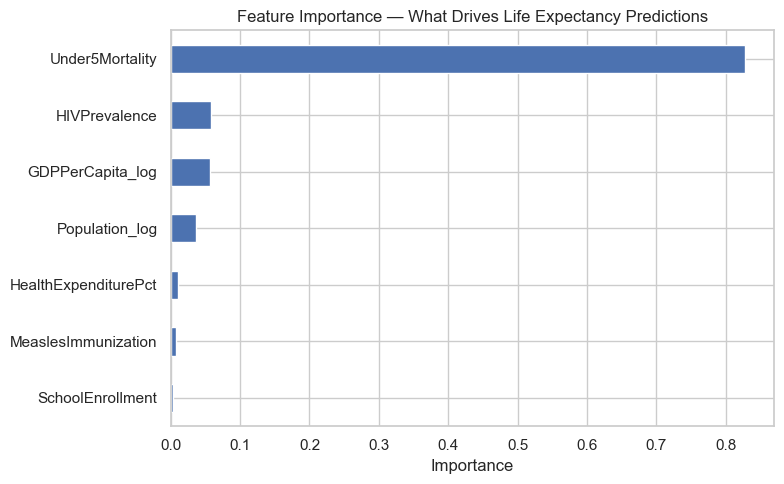

Under5Mortality         0.828098
HIVPrevalence           0.058129
GDPPerCapita_log        0.055953
Population_log          0.036473
HealthExpenditurePct    0.010222
MeaslesImmunization     0.007090
SchoolEnrollment        0.004035
dtype: float32

In [15]:
importances = pd.Series(best_model.feature_importances_, index=model_features).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importances.plot(kind='barh')
plt.title("Feature Importance — What Drives Life Expectancy Predictions")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

importances

**Findings**

Thus we are clear on the fact that Under5mortality is the strobgest predictor followed by HIVprevalence and GDPPerCapita_log.

## Predicted vs Actual

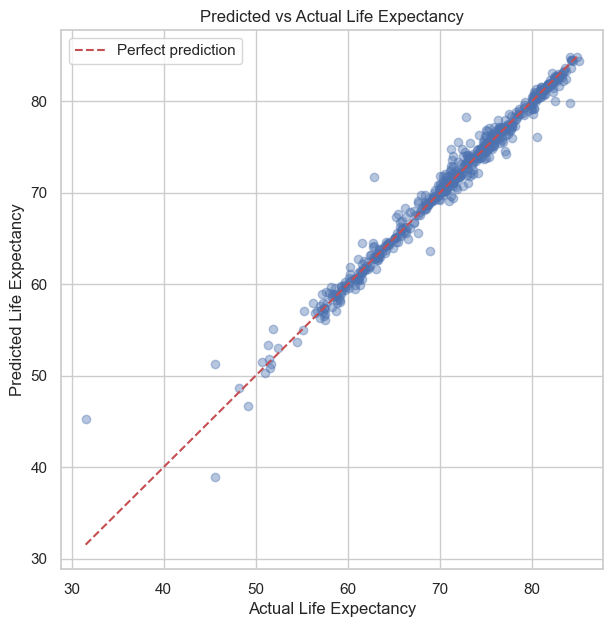

In [16]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect prediction')
plt.xlabel("Actual Life Expectancy")
plt.ylabel("Predicted Life Expectancy")
plt.title("Predicted vs Actual Life Expectancy")
plt.legend()
plt.show()

The scatter plot compares the model's predicted life expectancy with the actual values. Most data points lie very close to the red dashed line (perfect prediction), indicating that the model predicts life expectancy with high accuracy and minimal error. Only a few points deviate noticeably from the line, representing countries where the prediction error is relatively larger. This strong alignment is consistent with the model's excellent performance (R² = 0.979 and MAE = 0.63 years), confirming that it generalizes well and can reliably estimate life expectancy across different countries.

---
# PHASE 7 — Business/Policy Framing

In [17]:
# Identifying the 10 countries with the largest gap between predicted and actual —
# these are places where the model expects a different outcome than reality shows,
# worth a policy-relevant second look (over- or under-performing relative to their indicators)
test_results = X_test.copy()
test_results['Actual'] = y_test.values
test_results['Predicted'] = best_preds
test_results['Country'] = df.loc[X_test.index, 'Country Name'].values
test_results['Gap'] = test_results['Actual'] - test_results['Predicted']

print("Countries UNDER-performing relative to their indicators (worth investigating):")
print(test_results.nsmallest(5, 'Gap')[['Country', 'Actual', 'Predicted', 'Gap']])

print()
print("Countries OVER-performing relative to their indicators (worth learning from):")
print(test_results.nlargest(5, 'Gap')[['Country', 'Actual', 'Predicted', 'Gap']])

Countries UNDER-performing relative to their indicators (worth investigating):
                       Country  Actual  Predicted        Gap
460   Central African Republic  31.530  45.300526 -13.770526
296                    Bolivia  62.906  71.757835  -8.851835
1078                     Haiti  45.577  51.301449  -5.724449
2656       Trinidad and Tobago  72.882  78.284554  -5.402554
2463       St. Kitts and Nevis  71.181  74.832680  -3.651680

Countries OVER-performing relative to their indicators (worth learning from):
               Country     Actual  Predicted       Gap
2424       South Sudan  45.625000  38.906738  6.718262
2060             Palau  68.981000  63.677628  5.303372
869      Faroe Islands  80.604956  76.051338  4.553618
1616  Macao SAR, China  84.129268  79.772858  4.356411
2298        Seychelles  77.236585  74.185280  3.051306


**Takeaway:** 

The residual analysis highlights countries whose actual life expectancy differs significantly from the model's prediction. Under-performing countries (actual < predicted) may face additional challenges—such as political instability, conflict, healthcare accessibility, or socioeconomic inequalities—not captured by the selected features. Conversely, over-performing countries (actual > predicted) may benefit from effective public health policies, stronger healthcare systems, or other positive factors beyond the model's inputs. These cases represent valuable opportunities for further investigation and demonstrate that, while the model captures the major determinants of life expectancy, external real-world factors also play an important role.

---
# PHASE 8 — Save for Deployment

In [18]:
import joblib

joblib.dump(best_model, 'life_expectancy_model.pkl')
joblib.dump(scaler, 'life_expectancy_scaler.pkl')
joblib.dump(model_features, 'life_expectancy_features.pkl')

print("Saved: life_expectancy_model.pkl, life_expectancy_scaler.pkl, life_expectancy_features.pkl")

Saved: life_expectancy_model.pkl, life_expectancy_scaler.pkl, life_expectancy_features.pkl
